# Image Compression Autoencoder Experiments

This notebook prepares Amazon forest image patches, defines several autoencoder architectures, trains compression models, saves their checkpoints, and inspects reconstructed images. The data-acquisition cells are optional and remain commented out when an existing local dataset is used.

## Imports and Vision Studio Components

Load PyTorch, geospatial data clients, and the Vision Studio dataset, trainer, evaluator, metric, and reporting interfaces used by the remaining sections.

In [1]:
from pystac_client import Client
import planetary_computer
import stackstac
import torch
import torch.nn.functional as F
from vision_studio.models import BaseModel
from typing import Any
from torch import Tensor
from vision_studio.types import LossOutput
from vision_studio.trainer import Trainer
from vision_studio.dataset.image_only import ImageOnlyDataset
from vision_studio.data_loader import SimpleDataLoader
from vision_studio.trainer.trainer import VisionTrainer
from vision_studio.evaluate.base import LossEvaluator
from vision_studio.reporting.live_plot import LivePlotReporter
from vision_studio.evaluate.evaluator import LoopEvaluator
from vision_studio.evaluate.metrics import LossEvaluationMetrics
from vision_studio.types import EvaluatorOutput
from vision_studio.reporting.wandb import WandbReporter


## Local Paths and Compute Device

Select the local image dataset and use CUDA when available, otherwise falling back to CPU.

In [2]:
DATASET_PATH = "/home/mozi30/data/datasets/amazons_forest"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Sentinel-2 Scene Search

The following commented cell queries Microsoft Planetary Computer for low-cloud Sentinel-2 scenes over an Amazon-region bounding box. Enable it only when rebuilding the source imagery.

In [3]:
# # Amazon bounding box: [min_lon, min_lat, max_lon, max_lat]
# bbox = [-61.5, -4.5, -59.5, -2.5]

# catalog = Client.open(
#     "https://planetarycomputer.microsoft.com/api/stac/v1"
# )

# search = catalog.search(
#     collections=["sentinel-2-l2a"],
#     bbox=bbox,
#     datetime="2022-06-01/2022-09-30",
#     query={"eo:cloud_cover": {"lt": 10}},
#     max_items=20,
# )

# items = list(search.items())
# items = [planetary_computer.sign(item) for item in items]

# print("Found scenes:", len(items))

### RGB Composite

Stack the selected red, green, and blue bands at a common resolution and create a median temporal composite to reduce cloud and acquisition noise.

In [4]:
# bands = ["B04", "B03", "B02"]  # blue, green, red, NIR

# data = stackstac.stack(
#     items,
#     assets=bands,
#     bounds_latlon=bbox,
#     resolution=10,
#     epsg=32720,   # UTM zone 20S
# )

# # median composite over time
# composite = data.median(dim="time")
# print(composite.shape)

### Patch Export

Randomly sample fixed-size image patches from the composite, reject invalid patches, normalize valid RGB values, and save the resulting training images to the local dataset directory.

In [5]:
# from pathlib import Path
# import numpy as np

# out_dir = Path("/home/mozi30/data/datasets/amazons_forest")
# out_dir.mkdir(parents=True, exist_ok=True)

# patch_size = 512
# target_patches = 1000
# saved = 0
# attempts = 0
# max_attempts = target_patches * 10

# # composite shape: bands, height, width
# bands_count = composite.sizes["band"]
# height = composite.sizes["y"]
# width = composite.sizes["x"]

# while saved < target_patches and attempts < max_attempts:
#     attempts += 1

#     y = np.random.randint(0, height - patch_size)
#     x = np.random.randint(0, width - patch_size)

#     # load only this patch
#     patch = composite.isel(
#         y=slice(y, y + patch_size),
#         x=slice(x, x + patch_size)
#     ).values

#     patch = np.nan_to_num(patch)

#     if patch.mean() <= 0:
#         continue

#     patch = patch.astype(np.uint16)

#     np.save(out_dir / f"patch_{saved:04d}.npy", patch)
#     saved += 1

#     if saved % 100 == 0:
#         print(f"Saved {saved}/{target_patches}")

# print(f"Saved {saved} patches.")

## Baseline Convolutional Autoencoder

Define the original depth-configurable encoder and decoder. Max-pooling creates the compressed representation, transposed convolutions reconstruct the image, and mean squared error provides the training objective.

In [6]:
from vision_studio.types import InputSpec, OutputSpec, PostprocessOutput


class EncoderBlock(torch.nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = torch.nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.batch_norm = torch.nn.BatchNorm2d(out_channels)
        self.pool = torch.nn.MaxPool2d(2, ceil_mode=True)

    def forward(self, x):
        x = self.conv(x)
        x = self.batch_norm(x)
        x = torch.relu(x)
        x = self.pool(x)
        return x
    
class DecoderBlock(torch.nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = torch.nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.batch_norm = torch.nn.BatchNorm2d(out_channels)

    def forward(self, x):
        x = self.conv(x)
        x = self.batch_norm(x)
        x = torch.relu(x)
        return x

class Autoencoder(BaseModel):
    def __init__(self, encoder_depth=3, input_size=(1, 127, 127), base_channels=32, device: torch.device = torch.device("cpu")):
        super().__init__()

        self.input_size = input_size
        self.device = device
        in_channels = input_size[0]

        encoder_channels = [in_channels] + [
            base_channels * (2 ** i)
            for i in range(encoder_depth)
        ]

        self.encoder_blocks = torch.nn.ModuleList()
        for i in range(encoder_depth):
            self.encoder_blocks.append(
                EncoderBlock(
                    encoder_channels[i],
                    encoder_channels[i + 1],
                )
            )

        self.decoder_blocks = torch.nn.ModuleList()
        decoder_channels = list(reversed(encoder_channels[1:]))

        for i in range(encoder_depth - 1):
            self.decoder_blocks.append(
                DecoderBlock(
                    decoder_channels[i],
                    decoder_channels[i + 1],
                )
            )
            
        self.reconstruction = torch.nn.Sequential(
            torch.nn.ConvTranspose2d(decoder_channels[-1], base_channels, kernel_size=2, stride=2),
            torch.nn.ReLU(),
            torch.nn.Conv2d(base_channels, in_channels, kernel_size=3, padding=1),
            torch.nn.Sigmoid(),
        )
        self.to(device)


    def input_spec(self) -> InputSpec:
        return InputSpec(
            shape=self.input_size,
            dtype=torch.float32,
            device=self.device,
        )
    
    def output_spec(self) -> OutputSpec:
        return OutputSpec(
            shape=self.input_size,
            dtype=torch.float32,
        )
    
    def postprocess(self, logits: Tensor) -> PostprocessOutput:
        return PostprocessOutput(
            logits=logits
        )

    def forward(self, inputs):
        x = inputs
        for block in self.encoder_blocks:
            x = block(x)
        for block in self.decoder_blocks:
            x = block(x)
        x = self.reconstruction(x)
        return torch.nn.functional.interpolate(x, size=inputs.shape[-2:], mode="bilinear", align_corners=False)
    
    def compute_loss(
        self,
        logits: Tensor,
        targets: dict[str, Any],
    ) -> LossOutput:
        loss = torch.nn.functional.mse_loss(logits, targets["inputs"])
        return LossOutput(loss=loss)

## Explicit-Latent Autoencoder

Define `BetterAutoencoder`, which adds a configurable latent channel bottleneck, deeper convolution blocks, optional latent noise during training, and a mixed L1/MSE reconstruction loss.

In [7]:
class ConvBlock(torch.nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels, out_channels, 3, padding=1),
            torch.nn.BatchNorm2d(out_channels),
            torch.nn.ReLU(inplace=True),
            torch.nn.Conv2d(out_channels, out_channels, 3, padding=1),
            torch.nn.BatchNorm2d(out_channels),
            torch.nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class DownBlock(torch.nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels, out_channels, 4, stride=2, padding=1),
            torch.nn.BatchNorm2d(out_channels),
            torch.nn.ReLU(inplace=True),
            ConvBlock(out_channels, out_channels),
        )

    def forward(self, x):
        return self.net(x)


class UpBlock(torch.nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            torch.nn.Conv2d(in_channels, out_channels, 3, padding=1),
            torch.nn.BatchNorm2d(out_channels),
            torch.nn.ReLU(inplace=True),
            ConvBlock(out_channels, out_channels),
        )

    def forward(self, x):
        return self.net(x)


class BetterAutoencoder(BaseModel):
    def __init__(
        self,
        encoder_depth: int = 4,
        input_size: tuple[int, int, int] = (1, 128, 128),
        base_channels: int = 32,
        latent_channels: int = 8,
        add_latent_noise: bool = True,
        device: torch.device = torch.device("cpu"),
    ):
        super().__init__()

        self.input_size = input_size
        self.device = device
        self.add_latent_noise = add_latent_noise

        in_channels = input_size[0]

        channels = [base_channels * (2 ** i) for i in range(encoder_depth)]

        self.stem = ConvBlock(in_channels, channels[0])

        self.encoder = torch.nn.ModuleList()
        for i in range(encoder_depth - 1):
            self.encoder.append(DownBlock(channels[i], channels[i + 1]))

        bottleneck_channels = channels[-1]

        self.to_latent = torch.nn.Sequential(
            torch.nn.Conv2d(bottleneck_channels, latent_channels, kernel_size=1),
            torch.nn.Tanh(),
        )

        self.from_latent = torch.nn.Sequential(
            torch.nn.Conv2d(latent_channels, bottleneck_channels, kernel_size=1),
            torch.nn.ReLU(inplace=True),
        )

        decoder_channels = list(reversed(channels))

        self.decoder = torch.nn.ModuleList()
        for i in range(len(decoder_channels) - 1):
            self.decoder.append(
                UpBlock(decoder_channels[i], decoder_channels[i + 1])
            )

        self.reconstruction = torch.nn.Sequential(
            torch.nn.Conv2d(channels[0], channels[0], 3, padding=1),
            torch.nn.ReLU(inplace=True),
            torch.nn.Conv2d(channels[0], in_channels, 3, padding=1),
            torch.nn.Sigmoid(),
        )

        self.to(device)

    def input_spec(self) -> InputSpec:
        return InputSpec(
            shape=self.input_size,
            dtype=torch.float32,
            device=self.device,
        )

    def output_spec(self) -> OutputSpec:
        return OutputSpec(
            shape=self.input_size,
            dtype=torch.float32,
        )

    def postprocess(self, logits: Tensor) -> PostprocessOutput:
        return PostprocessOutput(logits=logits)

    def encode(self, x: Tensor) -> Tensor:
        x = self.stem(x)
        for block in self.encoder:
            x = block(x)

        z = self.to_latent(x)

        if self.training and self.add_latent_noise:
            z = z + torch.empty_like(z).uniform_(-1 / 255, 1 / 255)

        return z

    def decode(self, z: Tensor, output_size: tuple[int, int]) -> Tensor:
        x = self.from_latent(z)

        for block in self.decoder:
            x = block(x)

        x = self.reconstruction(x)

        if x.shape[-2:] != output_size:
            x = F.interpolate(
                x,
                size=output_size,
                mode="bilinear",
                align_corners=False,
            )

        return x

    def forward(self, inputs: Tensor) -> Tensor:
        z = self.encode(inputs)
        return self.decode(z, inputs.shape[-2:])

    def compute_loss(
        self,
        logits: Tensor,
        targets: dict[str, Any],
    ) -> LossOutput:
        inputs = targets["inputs"]

        l1 = F.l1_loss(logits, inputs)
        mse = F.mse_loss(logits, inputs)

        loss = 0.8 * l1 + 0.2 * mse

        return LossOutput(loss=loss)

## Quantized Compressive Autoencoder

Define `QuantizedCompressiveAutoencoder`, a residual architecture that discretizes its latent tensor with a straight-through estimator. Its loss combines reconstruction quality with a rate proxy weighted by `rate_weight`.

In [8]:
import torch
import torch.nn.functional as F
from torch import Tensor
from typing import Any

from vision_studio.types import InputSpec, OutputSpec, PostprocessOutput


class ResBlock(torch.nn.Module):
    def __init__(self, channels: int):
        super().__init__()

        self.net = torch.nn.Sequential(
            torch.nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            torch.nn.BatchNorm2d(channels),
            torch.nn.ReLU(inplace=True),
            torch.nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            torch.nn.BatchNorm2d(channels),
        )

    def forward(self, x: Tensor) -> Tensor:
        return F.relu(x + self.net(x), inplace=True)


class DownBlock(torch.nn.Module):
    def __init__(self, in_channels: int, out_channels: int, num_res_blocks: int = 2):
        super().__init__()

        self.down = torch.nn.Sequential(
            torch.nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=4,
                stride=2,
                padding=1,
            ),
            torch.nn.BatchNorm2d(out_channels),
            torch.nn.ReLU(inplace=True),
        )

        self.res_blocks = torch.nn.Sequential(
            *[ResBlock(out_channels) for _ in range(num_res_blocks)]
        )

    def forward(self, x: Tensor) -> Tensor:
        x = self.down(x)
        x = self.res_blocks(x)
        return x


class UpBlock(torch.nn.Module):
    def __init__(self, in_channels: int, out_channels: int, num_res_blocks: int = 2):
        super().__init__()

        self.up = torch.nn.Sequential(
            torch.nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            torch.nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            torch.nn.BatchNorm2d(out_channels),
            torch.nn.ReLU(inplace=True),
        )

        self.res_blocks = torch.nn.Sequential(
            *[ResBlock(out_channels) for _ in range(num_res_blocks)]
        )

    def forward(self, x: Tensor) -> Tensor:
        x = self.up(x)
        x = self.res_blocks(x)
        return x


class QuantizedCompressiveAutoencoder(BaseModel):
    def __init__(
        self,
        encoder_depth: int = 4,
        input_size: tuple[int, int, int] = (1, 128, 128),
        base_channels: int = 32,
        latent_channels: int = 8,
        num_res_blocks: int = 2,
        quantization_levels: int = 256,
        rate_weight: float = 1e-3,
        device: torch.device = torch.device("cpu"),
    ):
        super().__init__()

        self.input_size = input_size
        self.device = device
        self.latent_channels = latent_channels
        self.quantization_levels = quantization_levels
        self.rate_weight = rate_weight

        in_channels = input_size[0]

        channels = [
            base_channels * (2 ** i)
            for i in range(encoder_depth)
        ]

        self.stem = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels, channels[0], kernel_size=3, padding=1),
            torch.nn.BatchNorm2d(channels[0]),
            torch.nn.ReLU(inplace=True),
            ResBlock(channels[0]),
        )

        self.encoder = torch.nn.ModuleList()
        for i in range(encoder_depth - 1):
            self.encoder.append(
                DownBlock(
                    channels[i],
                    channels[i + 1],
                    num_res_blocks=num_res_blocks,
                )
            )

        bottleneck_channels = channels[-1]

        self.to_latent = torch.nn.Sequential(
            torch.nn.Conv2d(bottleneck_channels, latent_channels, kernel_size=1),
            torch.nn.Tanh(),
        )

        self.from_latent = torch.nn.Sequential(
            torch.nn.Conv2d(latent_channels, bottleneck_channels, kernel_size=1),
            torch.nn.BatchNorm2d(bottleneck_channels),
            torch.nn.ReLU(inplace=True),
        )

        decoder_channels = list(reversed(channels))

        self.decoder = torch.nn.ModuleList()
        for i in range(len(decoder_channels) - 1):
            self.decoder.append(
                UpBlock(
                    decoder_channels[i],
                    decoder_channels[i + 1],
                    num_res_blocks=num_res_blocks,
                )
            )

        self.reconstruction = torch.nn.Sequential(
            torch.nn.Conv2d(channels[0], channels[0], kernel_size=3, padding=1),
            torch.nn.ReLU(inplace=True),
            torch.nn.Conv2d(channels[0], in_channels, kernel_size=3, padding=1),
            torch.nn.Sigmoid(),
        )

        self._last_latent = None
        self._last_quantized_latent = None

        self.to(device)

    def input_spec(self) -> InputSpec:
        return InputSpec(
            shape=self.input_size,
            dtype=torch.float32,
            device=self.device,
        )

    def output_spec(self) -> OutputSpec:
        return OutputSpec(
            shape=self.input_size,
            dtype=torch.float32,
        )

    def postprocess(self, logits: Tensor) -> PostprocessOutput:
        return PostprocessOutput(logits=logits)

    def quantize_straight_through(self, z: Tensor) -> Tensor:
        """
        z is expected to be in [-1, 1] because of Tanh.

        We map:
            [-1, 1] -> [0, levels - 1]
        round to integers,
        then map back:
            [0, levels - 1] -> [-1, 1]

        Straight-through estimator:
            forward pass uses rounded values,
            backward pass treats quantization like identity.
        """
        levels = self.quantization_levels

        z_scaled = (z + 1.0) * 0.5 * (levels - 1)
        z_rounded = torch.round(z_scaled)
        z_quantized = (z_rounded / (levels - 1)) * 2.0 - 1.0

        return z + (z_quantized - z).detach()

    def encode(self, x: Tensor, quantize: bool = True) -> Tensor:
        x = self.stem(x)

        for block in self.encoder:
            x = block(x)

        z = self.to_latent(x)

        self._last_latent = z

        if quantize:
            z_q = self.quantize_straight_through(z)
        else:
            z_q = z

        self._last_quantized_latent = z_q

        return z_q

    def decode(self, z: Tensor, output_size: tuple[int, int]) -> Tensor:
        x = self.from_latent(z)

        for block in self.decoder:
            x = block(x)

        x = self.reconstruction(x)

        if x.shape[-2:] != output_size:
            x = F.interpolate(
                x,
                size=output_size,
                mode="bilinear",
                align_corners=False,
            )

        return x

    def forward(self, inputs: Tensor) -> Tensor:
        z_q = self.encode(inputs, quantize=True)
        return self.decode(z_q, inputs.shape[-2:])

    def compute_loss(
        self,
        logits: Tensor,
        targets: dict[str, Any],
    ) -> LossOutput:
        inputs = targets["inputs"]

        l1 = F.l1_loss(logits, inputs)
        mse = F.mse_loss(logits, inputs)

        reconstruction_loss = 0.85 * l1 + 0.15 * mse

        if self._last_quantized_latent is None:
            rate_loss = torch.tensor(0.0, device=logits.device)
        else:
            z = self._last_quantized_latent

            # Simple proxy for bitrate:
            # encourages smaller-magnitude and less information-heavy latent codes.
            rate_loss = z.abs().mean()

        loss = reconstruction_loss + self.rate_weight * rate_loss

        return LossOutput(loss=loss)

## Reconstruction Dataset and Training Services

Wrap each image as both the model input and reconstruction target, create train and validation data loaders, and configure the evaluator and trainer shared by the model experiments.

In [9]:

class ReconstructionDataset(torch.utils.data.Dataset):
    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        image, metadata = self.dataset[index]
        return image, {**metadata, "inputs": image}


dataset_train = ReconstructionDataset(ImageOnlyDataset(DATASET_PATH+"/train"))
dataset_val = ReconstructionDataset(ImageOnlyDataset(DATASET_PATH+"/val"))
data_loader_train = SimpleDataLoader(dataset_train, batch_size=4, shuffle=True)
data_loader_val = SimpleDataLoader(dataset_val, batch_size=8, shuffle=True)
reporter = WandbReporter() 
sample_input, _ = dataset_train[0]
model = Autoencoder(encoder_depth=4, input_size=tuple(sample_input.shape), base_channels=64, device=DEVICE)

adam_optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
metrics = LossEvaluationMetrics()
evaluator = LoopEvaluator(metrics=metrics, device=DEVICE) 
#trainer = VisionTrainer(adam_optimizer, evaluator, DEVICE, reporter=reporter)

## Quantized Model Training Sweep

Train quantized models across rate-loss weights and latent channel counts. Each completed run is saved as `rate_<weight>_latent_<channels>.pt` for later compression and segmentation analysis.

In [10]:
from vision_studio.reporting.base import ReporterContext


rate_weights = [5e-3, 1e-3, 1e-4]
latent_channels = [8,16,32]
for base in rate_weights:
    for latent in latent_channels:
        model = QuantizedCompressiveAutoencoder(
            encoder_depth=4,
            input_size=tuple(sample_input.shape),
            base_channels=32,
            num_res_blocks=2,
            quantization_levels=256,
            latent_channels=latent,
            rate_weight=base,
            device=DEVICE,
        )
        context = ReporterContext(
            mode = "train",
            project = "autoencoder",
            run_name="autoencoder_base_{}_latent_{}".format(base, latent), 
        )
        adam_optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        trainer = VisionTrainer(adam_optimizer, evaluator, DEVICE)
        trainer.fit(model,40,data_loader_train,data_loader_val)
        model.save_checkpoint("/home/mozi30/data/models/autoencoder/rate_{}_latent_{}.pt".format(base, latent))

## Reconstruction Inspection

Load a saved checkpoint, reconstruct a reproducibly selected validation image, and display the original and decoded images side by side for a qualitative quality check.

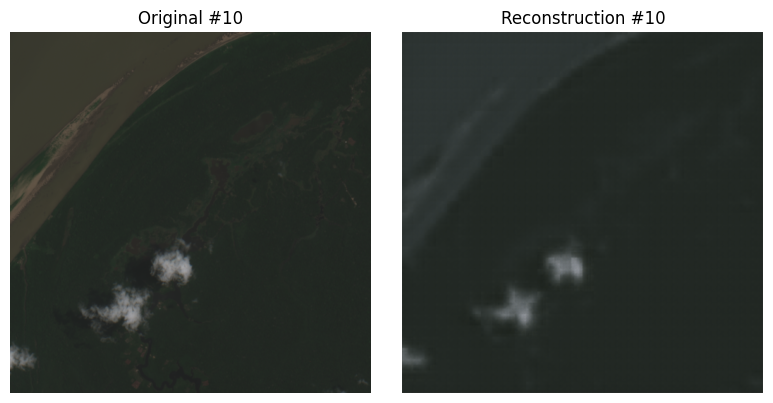

In [11]:
import random
import matplotlib.pyplot as plt
sample_input, _ = dataset_train[0]
model = Autoencoder(encoder_depth=4, input_size=tuple(sample_input.shape), base_channels=64, device=DEVICE)
model.load_checkpoint("/home/mozi30/data/models/autoencoder/encoder_depth_4_base_channel_64.pth")
model.eval()
random.seed(57)
sample_indices = random.sample(range(len(dataset_val)), k=1)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

with torch.no_grad():
    for _, index in enumerate(sample_indices):
        original = dataset_val[index][0]

        output = model(original.unsqueeze(0).to(DEVICE))

        original_image = original.detach().cpu().permute(1, 2, 0)
        recon_image = output.detach().cpu().squeeze(0).permute(1, 2, 0)

        axes[0].imshow(original_image.clamp(0, 1))
        axes[0].set_title(f"Original #{index}")
        axes[0].axis("off")

        axes[1].imshow(recon_image.clamp(0, 1))
        axes[1].set_title(f"Reconstruction #{index}")
        axes[1].axis("off")

plt.tight_layout()
plt.show()